### Stage 2: Watershed Aperture Extraction\nWe use `skimage.segmentation.watershed` to algorithmically map the perfect saddle points avoiding clump overlap.

In [6]:
import numpy as np
from astropy.io import fits
import sep
import matplotlib.pyplot as plt
from skimage.segmentation import watershed
from scipy.optimize import curve_fit
import os

os.makedirs('Watershed_Output', exist_ok=True)

# 1. Load Data
s3d_file = '../NIRSpec_IFU/COS-87259_BGSUB_g395h-f290lp_s3d.fits'
s3d = fits.open(s3d_file)
hdr = s3d['sci'].header
f3d = s3d['sci'].data
e3d = s3d['err'].data
fnu_0 = hdr['pixar_sr']

wl0, dwl, wl_len = hdr['CRVAL3'], hdr['CDELT3'], hdr['NAXIS3']
wl = wl0 + np.arange(wl_len) * dwl
wl_det = ((wl>3.75) & (wl<3.95)) | ((wl>5.05) & (wl<5.25))

ivw_stack = np.nanmean(f3d[wl_det]/e3d[wl_det]**2,axis=0) / np.nanmean(1./e3d[wl_det]**2,axis=0)
nan_mask = np.isnan(ivw_stack)
ivw_stack[nan_mask] = np.nan
bkg = sep.Background(ivw_stack, mask=nan_mask, bw=5, bh=5)
#stack_bkg_sub = ivw_stack - bkg
#stack_bkg_sub[nan_mask] = np.nan

# Same peak coordinates from Contour method
peaks = {
    'Center': {'y': 24, 'x': 27},
    'West': {'y': 24, 'x': 27}, 
    'North': {'y': 28, 'x': 27},
    'South': {'y': 15, 'x': 26},
    'Southeast': {'y': 20, 'x': 19}
}


C:\Users\zhigu\AppData\Local\Temp\ipykernel_24636\816209455.py:23: RuntimeWarning: Mean of empty slice
  ivw_stack = np.nanmean(f3d[wl_det]/e3d[wl_det]**2,axis=0) / np.nanmean(1./e3d[wl_det]**2,axis=0)


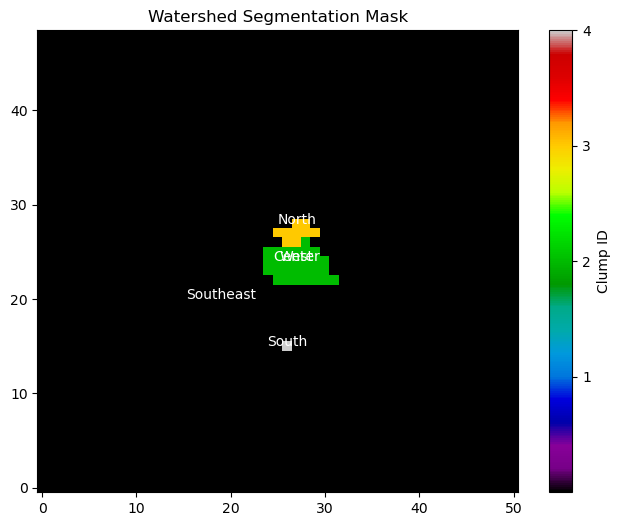

In [7]:
# Create Topography (-Flux) so bright peaks are deep valleys for the water
topography = -ivw_stack
topography[nan_mask] = 0

# Create Markers where the water source starts
markers = np.zeros_like(ivw_stack, dtype=np.int32)
clump_names = list(peaks.keys())
for i, name in enumerate(clump_names):
    p = peaks[name]
    markers[p['y'], p['x']] = i + 1

# Mask defining where the water is allowed to flood (above noise floor)
floor_mask = (ivw_stack > (bkg.back() + 3*bkg.globalrms)) & (~nan_mask)

# Run the Watershed Segmentation!
labels = watershed(topography, markers, mask=floor_mask)  #这里还可以加一个watershed_line函数：False，团块边界上的元素先到先得；True，边界不被标记为任何团块的部分。

# Plot the beautiful topological separation
plt.figure(figsize=(8,6))
img = plt.imshow(labels, origin='lower', cmap='nipy_spectral')
plt.title("Watershed Segmentation Mask")
plt.colorbar(img, ticks=range(1, 6), label='Clump ID')
for i, name in enumerate(clump_names):
    p = peaks[name]
    plt.text(p['x'], p['y'], name, color='white', fontsize=10, ha='center')
plt.show()


In [8]:
# Extract 1D definitive spectra using the watershed segments
y_grid, x_grid = np.indices(labels.shape) # 获取图像所有像素的Y和X坐标

for i, c_name in enumerate(clump_names):
    # 处理 Center 和 West 共用峰值导致 Marker 覆盖的问题
    if c_name == 'Center':
        # 复用被 West 覆盖的合并标签
        mask = (labels == clump_names.index('West') + 1)
    else:
        mask = (labels == i + 1)
    
    if not np.any(mask): continue
    
    # 实施手动空间切分（只修改当前掩模，不碰源数据 ivw_stack）
    if c_name == 'Center':
        # 限制在 y < 27 且 x < 29
        mask = mask & (y_grid < 27) & (x_grid < 29) #与运算，保留原mask（保留区域）与限定截取范围的交集
    elif c_name == 'West':
        # 限制在 y < 27 且 x >= 29
        mask = mask & (y_grid < 27) & (x_grid >= 29)
    elif c_name == 'North':
        # 排除 y < 27 的部分（即只保留 y >= 27）
        mask = mask & (y_grid >= 27)

    f1d, e1d = np.zeros(wl_len), np.zeros(wl_len)
    
    for j in range(wl_len):
        f1d[j] = np.nansum(f3d[j][mask]) * fnu_0
        e1d[j] = np.sqrt(np.nansum((e3d[j][mask])**2)) * fnu_0
        
    f1d = f1d * 1e-17 * 3e18 / (wl * 1e4)**2
    e1d = e1d * 1e-17 * 3e18 / (wl * 1e4)**2
    
    np.savetxt(f'Watershed_Output/{c_name}_spectrum.txt', np.column_stack((wl, f1d, e1d)), header='Wavelength_um Flux Err', comments='')

print("All definitive spectra saved to Watershed_Output/")



All definitive spectra saved to Watershed_Output/


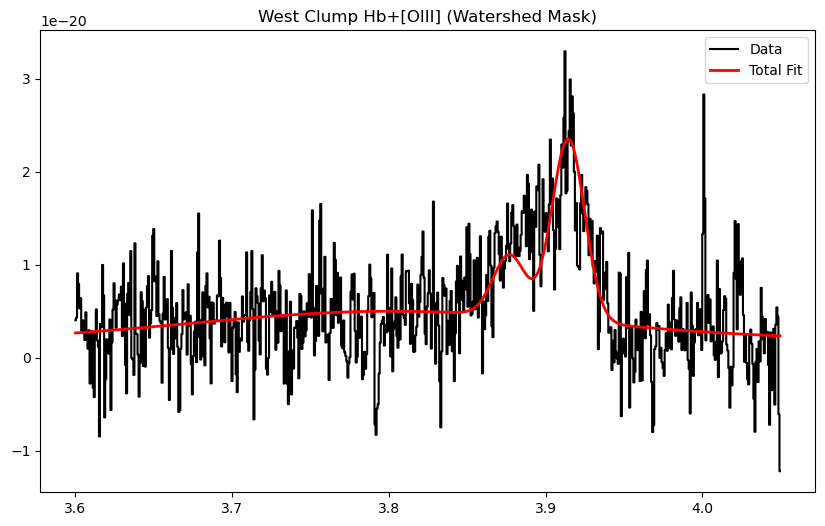

Narrow FWHM: 1884 km/s, Broad FWHM: 23550 km/s


In [9]:
# Fitting Logic Snippet
c_kms = 299792.458
wl_rest = {'Hb': 4861.33, 'O4959': 4958.91, 'O5007': 5006.84, 'N6548': 6548.05, 'Ha': 6562.81, 'N6584': 6583.45}
def gaussian(x, amp, cen, sig): return amp * np.exp(-(x-cen)**2 / (2*sig**2))

def model_HBOIII(x, m, c, z, amp_Hb_n, amp_Hb_b, amp_O4959, sig_v_n, sig_v_b):
    cont = m * x + c
    Hb_n = gaussian(x, amp_Hb_n, wl_rest['Hb']*(1+z), wl_rest['Hb']*(1+z)*(sig_v_n/c_kms))
    Hb_b = gaussian(x, amp_Hb_b, wl_rest['Hb']*(1+z), wl_rest['Hb']*(1+z)*(sig_v_b/c_kms))
    O49 = gaussian(x, amp_O4959, wl_rest['O4959']*(1+z), wl_rest['O4959']*(1+z)*(sig_v_n/c_kms))
    O50 = gaussian(x, amp_O4959 * 2.98, wl_rest['O5007']*(1+z), wl_rest['O5007']*(1+z)*(sig_v_n/c_kms))
    return cont + Hb_n + Hb_b + O49 + O50

# Fit the definitively segmented West clump as an example
w_data = np.loadtxt('Watershed_Output/West_spectrum.txt', skiprows=1)
vmask = w_data[:, 1] > -1e-18
wl_obs = w_data[vmask, 0] * 10000 
flux = w_data[vmask, 1] * 1e19 

win_mask = (wl_obs > 36000) & (wl_obs < 40500)
w1, f1 = wl_obs[win_mask], flux[win_mask]

p0 = [0, np.median(f1), 6.85, 1.0, 1.0, 1.0, 200, 3000]
bounds_min = [-np.inf, -100, 6.80, 0, 0, 0, 10, 800]
bounds_max = [np.inf, 100, 6.90, np.inf, np.inf, np.inf, 800, 10000]

popt, _ = curve_fit(model_HBOIII, w1, f1, p0=p0, bounds=(bounds_min, bounds_max), maxfev=10000)

plt.figure(figsize=(10,6))
plt.plot(w1/10000, f1/1e19, 'k-', label='Data', ds='steps-mid')
plt.plot(w1/10000, model_HBOIII(w1, *popt)/1e19, 'r-', label='Total Fit', lw=2)
plt.title("West Clump Hb+[OIII] (Watershed Mask)")
plt.legend()
plt.show()
print(f"Narrow FWHM: {popt[6]*2.355:.0f} km/s, Broad FWHM: {popt[7]*2.355:.0f} km/s")
